В этой домашке задания независимы

# Dropout (2 балла)

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler

In [3]:
input_dim = 784
num_categories = 10
batch_dim = 128

train_mnist = dsets.MNIST(root='./MNIST/',
                         train=True,
                         transform=transforms.ToTensor(),
                         download=True)

test_mnist = dsets.MNIST(root='./MNIST/',
                        train=False,
                        transform=transforms.ToTensor())

train_data_loader = torch.utils.data.DataLoader(dataset=train_mnist,
                                               batch_size=batch_dim,
                                               shuffle=False)

test_data_loader = torch.utils.data.DataLoader(dataset=test_mnist,
                                              batch_size=batch_dim,
                                              shuffle=False)

In [4]:
def evaluate_model(model):
    loss_log, acc_log = [], []
    model.eval()
    for batch_num, (x_batch, y_batch) in enumerate(test_data_loader):
        data_tensor = Variable(x_batch)
        target_tensor = Variable(y_batch)
        
        output_tensor = model(data_tensor)
        loss_val = F.nll_loss(output_tensor, target_tensor).cpu()
        
        predictions = torch.max(output_tensor, 1)[1].data.numpy()
        accuracy = np.mean(predictions == y_batch.numpy())
        acc_log.append(accuracy)
        
        loss_val = loss_val.item()
        loss_log.append(loss_val)
    return loss_log, acc_log

In [5]:
def train_one_epoch(model, optimizer, batchsize=32):
    loss_log, acc_log = [], []
    model.train()
    for batch_num, (x_batch, y_batch) in enumerate(train_data_loader):
        data_tensor = Variable(x_batch)
        target_tensor = Variable(y_batch)
        
        optimizer.zero_grad()
        output_tensor = model(data_tensor)
        
        predictions = torch.max(output_tensor, 1)[1].data.numpy()
        accuracy = np.mean(predictions == y_batch.numpy())
        acc_log.append(accuracy)
        
        loss_val = F.nll_loss(output_tensor, target_tensor)
        loss_val.backward()
        optimizer.step()
        loss_val = loss_val.item()
        loss_log.append(loss_val)
    return loss_log, acc_log

In [6]:
def plot_learning_curves(train_vals, valid_vals, title_name='loss'):
    plt.figure()
    plt.title(f'{title_name}')
    plt.plot(train_vals, label='train', zorder=1)
    
    points_array = np.array(valid_vals)
    plt.scatter(points_array[:, 0], points_array[:, 1], 
               marker='+', s=180, c='orange', label='val', zorder=2)
    plt.xlabel('training steps')
    plt.legend(loc='best')
    plt.grid()
    plt.show()


def model_training(model, optimizer, epochs_count):
    train_log, train_acc_log = [], []
    valid_log, valid_acc_log = [], []
    
    for epoch_idx in range(epochs_count):
        train_loss, train_acc = train_one_epoch(model, optimizer, batchsize=batch_dim)
        valid_loss, valid_acc = evaluate_model(model)
        
        train_log.extend(train_loss)
        train_acc_log.extend(train_acc)
        
        steps_count = train_mnist.train_labels.shape[0] / batch_dim
        valid_log.append((steps_count * (epoch_idx + 1), np.mean(valid_loss)))
        valid_acc_log.append((steps_count * (epoch_idx + 1), np.mean(valid_acc)))
        
        clear_output()
        plot_learning_curves(train_log, valid_log)
        plot_learning_curves(train_acc_log, valid_acc_log, title_name='accuracy')

Создайте простейшую однослойную модель - однослойную полносвязную сеть и обучите ее. Поскольку мнист это задача классификации, не забудте сделать последним слоем логсофтмакс для псевдовероятности.

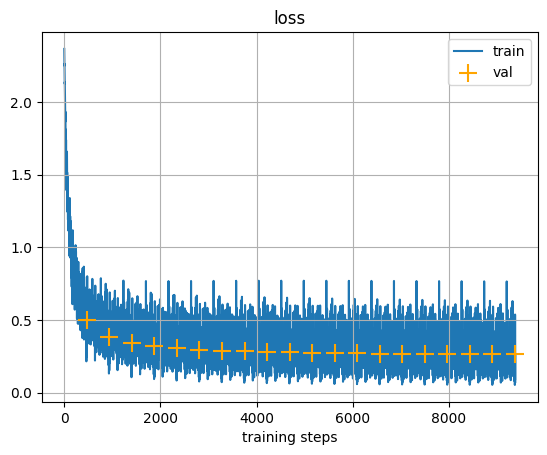

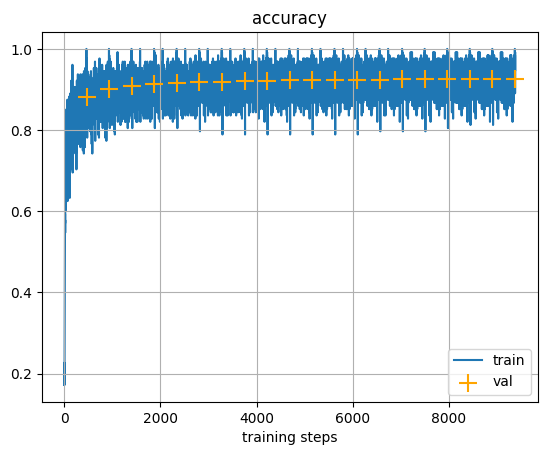

In [7]:
class ReshapeLayer(nn.Module):
    def forward(self, x):
        return x.view(x.size()[0], -1)


simple_model = nn.Sequential(
    ReshapeLayer(),
    nn.Linear(input_dim, num_categories),
    nn.LogSoftmax(dim=1)
)

optimizer_adam = torch.optim.Adam(simple_model.parameters(), lr=0.0005)
model_training(simple_model, optimizer_adam, 20)

Параметром обученной нейросети является матрица весов, в которой каждому классу соответствует один из 784-мерных столбцов. Их можно представить как двумерные изображения 28-28.

In [8]:
class CustomDropout(nn.Module):
    def __init__(self, drop_prob):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, input_tensor):
        if self.training:
            mask = torch.bernoulli(torch.full_like(input_tensor, 1 - self.drop_prob))
            scaling_factor = mask / (1 - self.drop_prob)
        else:
            scaling_factor = 1.0
        return torch.mul(input_tensor, scaling_factor)

In [9]:
dropout_prob = 0.7

model_with_dropout = nn.Sequential(
    ReshapeLayer(),
    CustomDropout(dropout_prob),
    nn.Linear(input_dim, num_categories),
    nn.LogSoftmax(dim=1)
)

Добавьте Dropout-слой в архитектуру сети, проведите оптимизацию с параметрами, заданными ранее, визуализируйте обученные веса. Есть ли разница между весами, обученными с Dropout и без него? Параметр Dropout возьмите равным 0.7

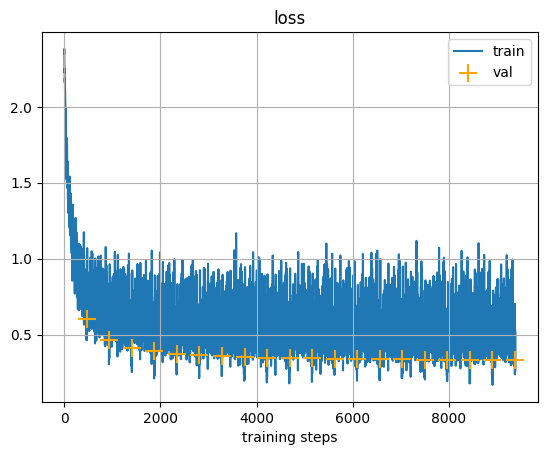

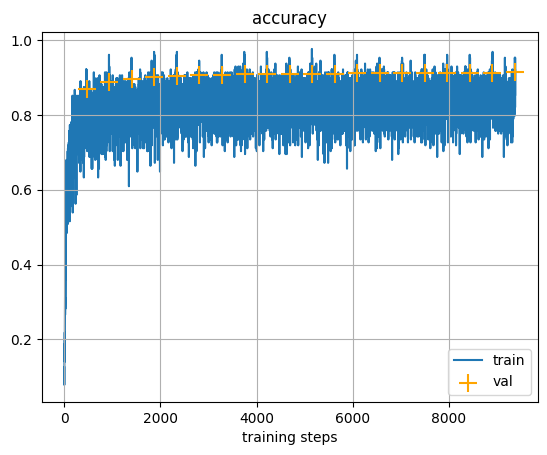

In [10]:
optimizer_dropout = torch.optim.Adam(model_with_dropout.parameters(), lr=0.0005)
model_training(model_with_dropout, optimizer_dropout, 20)

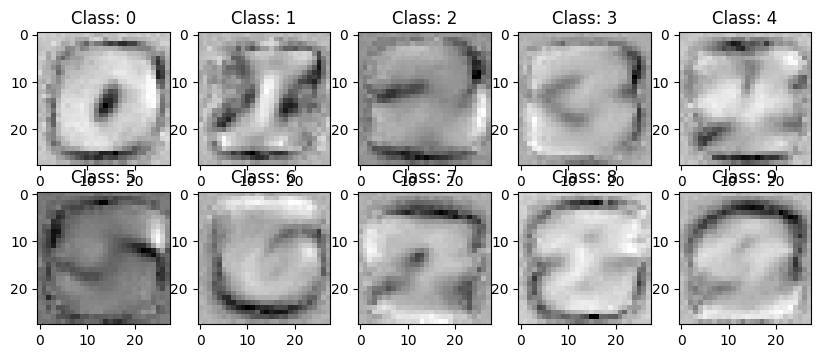

In [11]:
weights_dropout = list(model_with_dropout.parameters())[0].data.numpy()
plt.figure(figsize=[10, 10])
for class_idx in range(10):
    plt.subplot(5, 5, class_idx + 1)
    plt.title(f"Class: {class_idx}")
    plt.imshow(weights_dropout[class_idx].reshape([28, 28]), cmap='gray')

# Metric Learning (3 балла)

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data.sampler import Sampler, BatchSampler
from torch.nn.modules.loss import MSELoss

Contrastive Loss - одна из самых популярных функций потерь для metric learning. Contrastive Loss получает на вход пару векторов $x_i$ и $x_j$ и метку $y_{ij}$, причем $y_{ij} = 0$, если объекты "похожи" (принадлежат одному классу), и $y_{ij} = 1$, если объекты "различны" (принадлежат различным классам). Формально определим Contrastive Loss следующим образом:

$$
L(x_i, x_j, y_{ij}) = (1 - y_{ij})\|x_i - x_j\|^2 + y_{ij}max(0, m - \|x_i - x_j\|^2)
$$

где $m$ - гиперпараметр (его можно взять равным единице).

Вместо того, чтобы формировать обучающее множество из всевозможных пар, можно поступить проще: будем пропускать батч из $N$ обучаюших изображений через сеть (тем самым получая соответствующие векторы $x$), а значение лосса вычислять как среднее значение функции $L$ на всех парах в этом батче. Тогда в обучении на каждом батче участвует $\frac{N(N-1)}{2}$ пар, что существенно ускоряет сходимость на практике. Реализуйте предложенный вариант Contrastive Loss.

In [13]:
class PairwiseContrastiveLoss(torch.nn.Module):
    def __init__(self, margin_val=1.0):
        super(PairwiseContrastiveLoss, self).__init__()
        self.margin_val = margin_val

    def forward(self, embeddings, class_labels):
        batch_size = embeddings.size()[0]
        dist_matrix = torch.cdist(embeddings, embeddings, p=2) ** 2

        labels_expanded = class_labels.unsqueeze(1).expand(batch_size, batch_size)
        diff_labels = (labels_expanded != labels_expanded.t()).float()
        
        positive_pairs = (1 - diff_labels) * dist_matrix
        
        negative_pairs = diff_labels * torch.clamp(self.margin_val - dist_matrix, min=0)

        total_loss = (positive_pairs + negative_pairs).sum() / (batch_size * (batch_size - 1))
        return total_loss


В задачах metric learning, как правило, необходимо, чтобы количества "положительных" и "отрицательных" пар в обучении отличалось несильно. Поэтому в случае большого количества классов случайное формирование батчей неэффективно - в таком случае количество "положительных" пар очень мало. Поэтому будем формировать обучающие батчи размера $N$ следующим образом: будем брать $\frac{N}{2}$ элементов из некоторого класса (они между собой будут формировать "положительные пары"), а оставшиеся $\frac{N}{2}$ элементов будем брать случайно. Таким образом мы гарантируем, что в каждом обучающем батче будет достаточно "положительных" пар.

In [14]:
from collections import defaultdict

В этом задании будем работать с небольшими изображениями одежды из датасета Fashion-MNIST.

In [15]:
class BalancedBatchSampler(BatchSampler):
    def __init__(self, batch_sz, class_count, labels_tensor):
        self.class_count = class_count
        self.images_per_class = labels_tensor.size()[0] // class_count
        class_indices = defaultdict(list)
        for idx, lbl in enumerate(labels_tensor):
            class_indices[lbl.item()].append(idx)
        self.batch_sz = batch_sz
        self.class_indices = class_indices
        self.total_samples = len(labels_tensor)

    def __iter__(self):
        samples_yielded = 0
        while samples_yielded < (self.class_count * self.images_per_class):
            current_batch = []
            base_class = np.random.randint(0, self.class_count)
            positive_samples = np.random.choice(
                self.class_indices[base_class], 
                size=self.batch_sz // 2
            ).tolist()
            negative_samples = np.random.randint(
                self.total_samples, 
                size=self.batch_sz // 2
            ).tolist()
            current_batch += positive_samples + negative_samples
            samples_yielded += self.batch_sz
            yield current_batch

In [17]:
fashion_train = dsets.FashionMNIST(root='.',
                                  train=True,
                                  transform=transforms.ToTensor(),
                                  download=True)

fashion_test = dsets.FashionMNIST(root='.',
                                 train=False,
                                 transform=transforms.ToTensor())

contrastive_loss_fn = PairwiseContrastiveLoss()

fashion_train_loader = torch.utils.data.DataLoader(
    dataset=fashion_train,
    batch_sampler=BalancedBatchSampler(
        batch_sz=batch_dim,
        class_count=num_categories, 
        labels_tensor=fashion_train.train_labels
    ),
    shuffle=False
)

fashion_test_loader = torch.utils.data.DataLoader(
    dataset=fashion_test,
    batch_sampler=BalancedBatchSampler(
        batch_sz=batch_dim,
        class_count=num_categories, 
        labels_tensor=fashion_test.test_labels
    ),
    shuffle=False
)


c:\Users\nikit\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
c:\Users\nikit\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


Реализуйте сеть несложной архитектуры, содержащую три сверточных слоя из 20 фильтров с макс-пулингом, а также два полносвязных слоя из 128 нейронов. Выход последнего слоя будет подаваться на вход Contrastive Loss.

In [19]:
class EmbeddingNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 20, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            
            nn.Conv2d(20, 20, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            
            nn.Conv2d(20, 20, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),
            
            ReshapeLayer(),
            
            nn.Linear(20 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 128)
        )

    def forward(self, x):
        return self.features(x)


def train_embedding_epoch(model, optimizer):
    loss_history = []
    model.train()
    for batch_data, batch_labels in fashion_train_loader:
        inputs = Variable(batch_data)
        targets = Variable(batch_labels)
        optimizer.zero_grad()
        embeddings = model(inputs)
        loss_val = contrastive_loss_fn(embeddings, targets)
        loss_val.backward()
        optimizer.step()
        loss_history.append(loss_val.item())
    return loss_history


def evaluate_embedding_model(model):
    loss_history = []
    model.eval()
    for batch_data, batch_labels in fashion_test_loader:
        inputs = Variable(batch_data)
        targets = Variable(batch_labels)
        embeddings = model(inputs)
        loss_val = contrastive_loss_fn(embeddings, targets)
        loss_history.append(loss_val.item())
    return loss_history


def plot_training_curves(train_hist, valid_hist, title_text='loss'):
    plt.figure()
    plt.title(f'{title_text}')
    plt.plot(train_hist, label='train', zorder=1)
    points = np.array(valid_hist)
    plt.scatter(points[:, 0], points[:, 1], 
               marker='+', s=180, c='orange', label='val', zorder=2)
    plt.xlabel('training steps')
    plt.legend(loc='best')
    plt.grid()
    plt.show()


def train_embedding_model(model, optimizer, num_epochs):
    train_log = []
    val_log = []

    for epoch in range(num_epochs):
        train_losses = train_embedding_epoch(model, optimizer)
        val_losses = evaluate_embedding_model(model)
        train_log.extend(train_losses)
        steps = fashion_train.train_labels.shape[0] / batch_dim
        val_log.append((steps * (epoch + 1), np.mean(val_losses)))
        clear_output()
        plot_training_curves(train_log, val_log)

Обучите сеть с параметрами, указанными ниже.

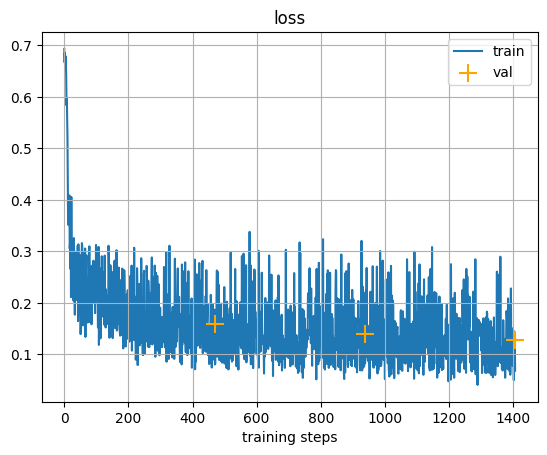

In [20]:
embedding_model = EmbeddingNetwork()
opt = torch.optim.Adam(embedding_model.parameters(), lr=0.0005)
train_embedding_model(embedding_model, opt, 3)

Извлеките векторные описания тестовых изображений (a.k.a эмбеддинги). У вас должно получиться 10000 128-мерных векторов.

In [21]:
test_data = fashion_test.test_data
test_embeddings = embedding_model(Variable(test_data.view(-1, 1, 28, 28)).float())

Код ниже демонстрирует поисковую выдачу для трех изображений-запросов. Выдача формируется на основе близости эмбеддингов.

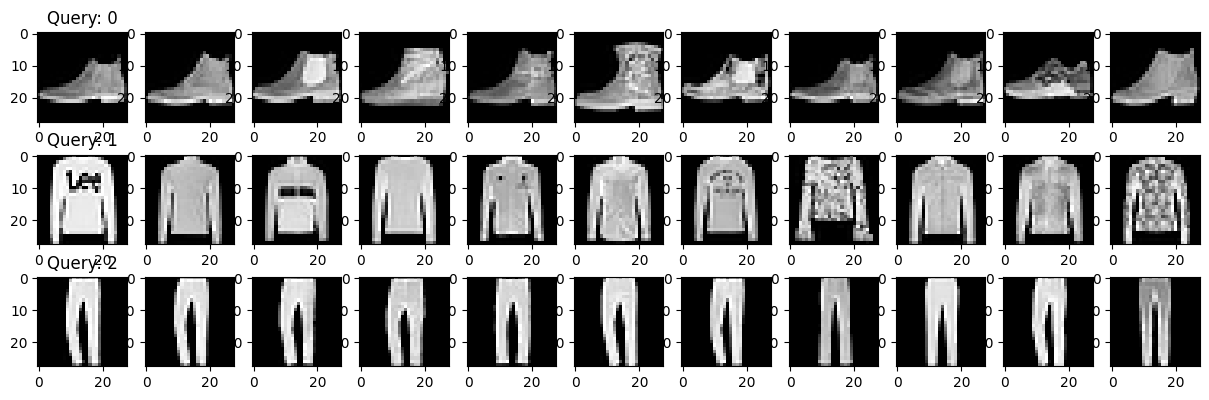

In [22]:
query_count = 3
queries_array = test_embeddings[:query_count, :].data.numpy()
database_array = test_embeddings[query_count:, :].data.numpy()
plt.figure(figsize=[15, 4.5])
for q_idx in range(query_count):
    distances = np.sum((database_array - queries_array[q_idx, :]) ** 2, axis=1)
    nearest_indices = np.argsort(distances)[:10]
    
    plt.subplot(query_count, 11, q_idx * 11 + 1)
    plt.title(f"Query: {q_idx}")
    plt.imshow(fashion_test.test_data[q_idx].numpy().reshape([28, 28]), cmap='gray')
    
    for k in range(10):
        plt.subplot(query_count, 11, q_idx * 11 + k + 2)
        img_idx = nearest_indices[k] + query_count
        plt.imshow(fashion_test.test_data[img_idx].numpy().reshape([28, 28]), cmap='gray')
plt.show()

# Super-resolution (3 балла)

В этой части вам предстоит реализовать простейшую архитектуру для решения задачи image super-resolution.

In [23]:
sr_train_loader = torch.utils.data.DataLoader(dataset=train_mnist,
                                             batch_size=batch_dim,
                                             shuffle=False)

sr_test_loader = torch.utils.data.DataLoader(dataset=test_mnist,
                                            batch_size=batch_dim,
                                            shuffle=False)


Мы будем увеличивать изображения размера (14,14) в два раза по каждому измерению. Как правило, перед подачей на вход нейросети изображение низкого разрешения увеличивают до нужного размера билинейной интерполяцией, а нейросеть улучшает результат интерпляции, не меняя пространственные размеры изображения.

Реализуйте нейросеть из трех сверточных слоев, которая будет получать на вход черно-белое изображение и выдавать на выход изображение такого же размера. Нейросеть должна предсказывать добавку, которую необходимо прибавить к полученному на вход изображению низкого качества.

In [24]:
class ResidualSuperResolution(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        residual = self.layers(x)
        return residual + x

In [25]:
def create_low_res_batch(original_batch):
    result = original_batch.clone()
    low_res = transforms.Resize((14, 14))
    high_res = transforms.Resize((28, 28))
    to_tensor = transforms.ToTensor()
    to_image = transforms.ToPILImage()
    
    for i in range(original_batch.size()[0]):
        img = to_image(original_batch[i])
        low_img = low_res(img)
        upscaled = high_res(low_img)
        result[i] = to_tensor(upscaled)
    return result


def train_sr_epoch(model, optimizer):
    loss_log = []
    model.train()
    for batch_num, (x_batch, _) in enumerate(sr_train_loader):
        x_batch = x_batch.float() / 255
        inputs = Variable(create_low_res_batch(x_batch))
        targets = Variable(x_batch)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = F.mse_loss(outputs, targets)
        loss.backward()
        optimizer.step()
        loss_log.append(loss.data.item())
    return loss_log


def evaluate_sr_model(model):
    loss_log = []
    model.eval()
    for batch_num, (x_batch, _) in enumerate(sr_test_loader):
        x_batch = x_batch.float() / 255
        inputs = Variable(create_low_res_batch(x_batch))
        targets = Variable(x_batch)
        outputs = model(inputs)
        loss = F.mse_loss(outputs, targets)
        loss_log.append(loss.data.item())
    return loss_log


def plot_sr_history(train_history, val_history, title='loss'):
    plt.figure()
    plt.title(f'{title}')
    plt.plot(train_history, label='train', zorder=1)
    points = np.array(val_history)
    plt.scatter(points[:, 0], points[:, 1], 
               marker='+', s=180, c='orange', label='val', zorder=2)
    plt.xlabel('training steps')
    plt.legend(loc='best')
    plt.grid()
    plt.show()


def train_sr_model(model, optimizer, num_epochs):
    train_log = []
    val_log = []
    
    for epoch in range(num_epochs):
        train_losses = train_sr_epoch(model, optimizer)
        val_losses = evaluate_sr_model(model)
        train_log.extend(train_losses)
        steps = train_mnist.train_labels.shape[0] / batch_dim
        val_log.append((steps * (epoch + 1), np.mean(val_losses)))
        clear_output()
        plot_sr_history(train_log, val_log)


Оптимизируйте сеть с параметрами, указанными ниже.

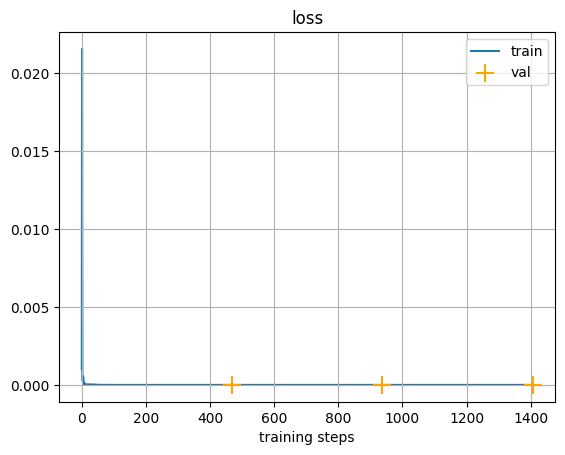

In [26]:
sr_model = ResidualSuperResolution()
sr_optimizer = torch.optim.Adam(sr_model.parameters(), lr=0.005, weight_decay=0.05)
train_sr_model(sr_model, sr_optimizer, 3)

In [27]:
test_imgs = test_mnist.test_data.float() / 255
sr_results = sr_model(Variable(create_low_res_batch(test_imgs.view(-1, 1, 28, 28))))

Код ниже визуализирует исходные изображения (28,28) и реконструкции, полученные с помощью нейросети.
Не удивляйтесь, есть качество реконструкций покажется низким, MSE-loss, не является оптимальным для задачи super-resolution (гораздо лучше работают GANы, расскажу позже).

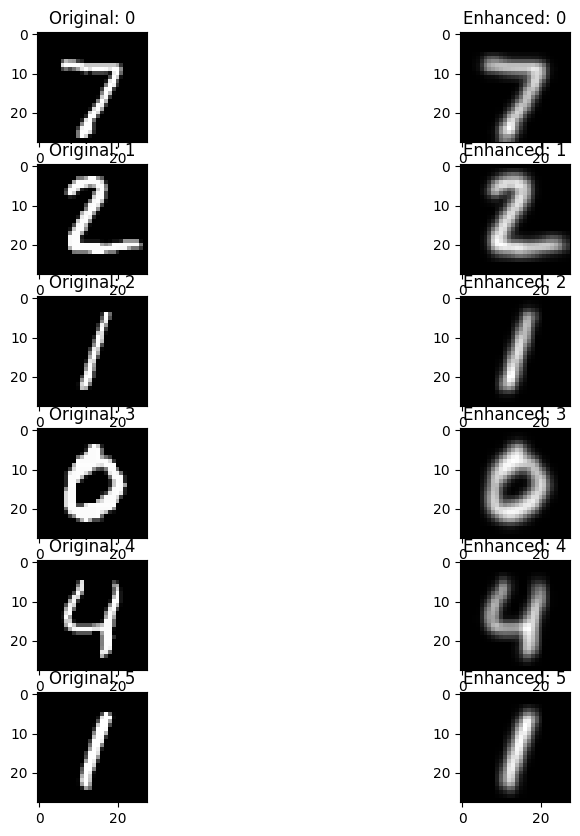

In [28]:
example_count = 6
plt.figure(figsize=[10, 10])
for idx in range(example_count):
    plt.subplot(example_count, 2, idx * 2 + 1)
    plt.title(f"Original: {idx}")
    plt.imshow(test_mnist.test_data[idx].numpy().reshape([28, 28]), cmap='gray')
    
    plt.subplot(example_count, 2, idx * 2 + 2)
    plt.title(f"Enhanced: {idx}")
    plt.imshow(sr_results[idx].data.numpy().reshape([28, 28]), cmap='gray')
plt.show()